# CSCE 5218 - Deep Learning
## Lab: Word2Vec from Scratch with Negative Sampling

**Estimated time:** 90-120 minutes  
**Environment:** Python 3.9+, NumPy, Matplotlib, scikit-learn  
**Submission:** Completed notebook with code outputs and written responses

In this lab, you will implement the skip-gram with negative sampling (SGNS) version of Word2Vec using NumPy. The corpus is embedded in the notebook, so no download is required.

> **Academic integrity:** You may use AI tools for clarification, debugging, and boilerplate. Your implementation choices, experiments, analysis, and written explanations must be your own. Disclose meaningful AI assistance.

### Learning objectives

By the end of the lab, you should be able to:

1. Convert tokenized text into skip-gram center-context training pairs.
2. Explain why negative sampling makes Word2Vec computationally efficient.
3. Derive and implement the SGNS loss and gradients.
4. Train and diagnose word embeddings using held-out loss.
5. Evaluate embeddings with nearest neighbors, analogies, and visualization.
6. Identify limitations of conclusions drawn from a small corpus.

### Mathematical model

For a center word $c$, a true context word $o$, and $K$ negative samples $n_1,\ldots,n_K$, SGNS minimizes

$$\mathcal{L}=-\log \sigma(u_o^T v_c)-\sum_{k=1}^{K}\log \sigma(-u_{n_k}^T v_c),$$

where $v_c$ is an input embedding, $u_o$ and $u_{n_k}$ are output embeddings, and $\sigma(x)=1/(1+e^{-x})$.

The positive term increases the center-context dot product. The negative terms decrease dot products for randomly sampled words.

In [30]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

print('NumPy:', np.__version__)

NumPy: 2.5.2


## 1. Build a controlled corpus

A controlled corpus lets us inspect what Word2Vec learns from repeated co-occurrence patterns. It is useful pedagogically, but it is not a substitute for a natural, large-scale corpus.

In [43]:
RAW_SENTENCES = [
    'king is a royal man', 'queen is a royal woman',
    'prince is a young royal man', 'princess is a young royal woman',
    'king and queen rule the kingdom', 'prince and princess live in the palace',
    'king wears a crown in the palace', 'queen wears a crown in the palace',
    'man and woman are adults', 'boy and girl are young',
    'paris is the capital of france', 'berlin is the capital of germany',
    'rome is the capital of italy', 'madrid is the capital of spain',
    'tokyo is the capital of japan', 'beijing is the capital of china',
    'france has the city paris', 'germany has the city berlin',
    'italy has the city rome', 'spain has the city madrid',
    'japan has the city tokyo', 'china has the city beijing',
    'dog is a loyal animal', 'cat is a quiet animal',
    'puppy is a young dog', 'kitten is a young cat',
    'dog and cat are common pets', 'puppy and kitten are young pets',
    'horse is a large animal', 'foal is a young horse',
    'apple is a sweet fruit', 'banana is a yellow fruit',
    'grape is a small fruit', 'orange is a citrus fruit',
    'red apple and yellow banana are fruit',
    'purple grape and orange citrus are fruit',
    'doctor works in a hospital', 'nurse works in a hospital',
    'teacher works in a school', 'student learns in a school',
    'doctor treats a patient', 'teacher teaches a student',
    'programmer writes computer code', 'computer executes code',
    'researcher studies data', 'scientist analyzes data',
    'river carries water', 'ocean contains water',
    'mountain is high', 'valley is low',
]

# Repeat patterns to create enough training observations, then shuffle reproducibly.
sentences = [s.lower().split() for s in RAW_SENTENCES for _ in range(20)]
rng.shuffle(sentences)

counts = Counter(token for sentence in sentences for token in sentence)
vocab = sorted(counts)
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}
encoded_sentences = [[word_to_id[w] for w in sentence] for sentence in sentences]

print(f'{len(sentences):,} sentences, {len(vocab)} vocabulary items')
print('Most common:', counts.most_common(10))
print(id_to_word)

1,000 sentences, 92 vocabulary items
Most common: [('a', 440), ('is', 440), ('the', 320), ('and', 160), ('in', 140), ('young', 140), ('capital', 120), ('of', 120), ('fruit', 120), ('has', 120)]
{0: 'a', 1: 'adults', 2: 'analyzes', 3: 'and', 4: 'animal', 5: 'apple', 6: 'are', 7: 'banana', 8: 'beijing', 9: 'berlin', 10: 'boy', 11: 'capital', 12: 'carries', 13: 'cat', 14: 'china', 15: 'citrus', 16: 'city', 17: 'code', 18: 'common', 19: 'computer', 20: 'contains', 21: 'crown', 22: 'data', 23: 'doctor', 24: 'dog', 25: 'executes', 26: 'foal', 27: 'france', 28: 'fruit', 29: 'germany', 30: 'girl', 31: 'grape', 32: 'has', 33: 'high', 34: 'horse', 35: 'hospital', 36: 'in', 37: 'is', 38: 'italy', 39: 'japan', 40: 'king', 41: 'kingdom', 42: 'kitten', 43: 'large', 44: 'learns', 45: 'live', 46: 'low', 47: 'loyal', 48: 'madrid', 49: 'man', 50: 'mountain', 51: 'nurse', 52: 'ocean', 53: 'of', 54: 'orange', 55: 'palace', 56: 'paris', 57: 'patient', 58: 'pets', 59: 'prince', 60: 'princess', 61: 'programm

### Task 1 - Inspect the corpus

1. Why will frequent function words such as `a`, `is`, and `the` dominate the training pairs?
2. Predict two semantic clusters the model should learn.
3. Predict one relationship the model is unlikely to learn reliably from this corpus.

**Your response:**  

1) Because of their frequent use, they repeatedly become both center and context words, creating many training pairs.
2) 
 - Royalty: king, queen, prince, princess, royal 
 - Fruit: apple, banana, grape, orange, fruit, sweet, yellow, small, citrus, red, purple 
3) The model is unlikely to reliably learn that river, ocean, mountain, and valley are all geographic features, because the corpus gives little shared context connecting all four words.

## 2. Generate skip-gram training pairs

For each center token, pair it with every token within a fixed window. Do not pair a token position with itself.

In [32]:
def build_skipgram_pairs(encoded, window_size=2):
    # TODO: Return aligned int64 arrays of center IDs and context IDs.
    # For every token position, include all valid neighbors within the window,
    # but never pair a position with itself.
    centers = []
    contexts = []

    for sentence in encoded:
        for i, center_id in enumerate(sentence):
            # Get the context IDs within the window
            start = max(0, i - window_size)
            end = min(len(sentence), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    contexts.append(sentence[j])
                    centers.append(center_id)

    return np.array(centers, dtype=np.int64), np.array(contexts, dtype=np.int64)

centers, contexts = build_skipgram_pairs(encoded_sentences, window_size=2)
assert centers.shape == contexts.shape
assert len(centers) > 0

print(f'{len(centers):,} positive pairs')
for c, o in zip(centers[:10], contexts[:10]):
    print(f'{id_to_word[c]:>10s} -> {id_to_word[o]}')

14,320 positive pairs
  mountain -> is
  mountain -> high
        is -> mountain
        is -> high
      high -> mountain
      high -> is
     river -> carries
     river -> water
   carries -> river
   carries -> water


### Checkpoint 1

Explain how increasing `window_size` changes both the number and the meaning of the positive pairs.

**Your response:**  

Increasing window_size creates more positive pairs, until it reaches the sentence boundaries. Each center word can pair with more surrounding words.

A larger window also includes words that are farther apart, so the pairs represent broader ideas. A smaller window focuses more on immediate word relationships and local grammar.

## 3. Train/validation split and negative-sampling distribution

The original Word2Vec implementation samples negatives approximately according to unigram frequency raised to the $3/4$ power. This reduces the dominance of extremely frequent words while still sampling common words often.

In [33]:
order = rng.permutation(len(centers))
split = int(0.90 * len(order))
train_idx, val_idx = order[:split], order[split:]
train_centers, train_contexts = centers[train_idx], contexts[train_idx]
val_centers, val_contexts = centers[val_idx], contexts[val_idx]

def make_negative_distribution(counts, vocab, power=0.75):
    # TODO: Build the normalized unigram^power probability distribution.

    unigram_probs = np.array([counts.get(word, 0) for word in vocab]).astype(np.float64)
    unigram_probs **= power
    unigram_probs /= unigram_probs.sum()

    return unigram_probs

negative_probs = make_negative_distribution(counts, vocab)
assert np.isclose(negative_probs.sum(), 1.0)

def sample_negatives(batch_size, k, positive_contexts, rng):
    negatives = rng.choice(len(vocab), size=(batch_size, k), p=negative_probs)
    invalid = negatives == positive_contexts[:, None]
    while invalid.any():
        negatives[invalid] = rng.choice(len(vocab), size=invalid.sum(), p=negative_probs)
        invalid = negatives == positive_contexts[:, None]
    return negatives

print('Train pairs:', len(train_centers), 'Validation pairs:', len(val_centers))

Train pairs: 12888 Validation pairs: 1432


### Task 2 - Reason about negative sampling

Why is a negative-sampling objective cheaper than a full softmax over a vocabulary of size $V$? If the embedding dimension is $d$, compare the approximate per-example complexity.

**Your response:**  

A full softmax compares the center word to all words in the vocabulary. Each vector of $V$ would have the computed dot product between the 2 vectors of length $d$. Giving the per-example complexity of $O(Vd)$. Using negative sampling, the center word is compared with 1 actual context word and K randomly chosen negative words. This gives the per-example complexity of $O(Kd)$. Since $K$ is a fixed small number, $K$ would be much smaller than $V$, as it is the whole vocabulary.

## 4. Implement SGNS loss and gradients

Let $s^+=u_o^T v_c$ and $s_k^-=u_{n_k}^T v_c$. For one example:

$$\frac{\partial \mathcal{L}}{\partial s^+}=\sigma(s^+)-1, \qquad \frac{\partial \mathcal{L}}{\partial s_k^-}=\sigma(s_k^-).$$

In [34]:
def sigmoid(x):
    x = np.clip(x, -30.0, 30.0)
    return 1.0 / (1.0 + np.exp(-x))

def logsigmoid(x):
    return -np.logaddexp(0.0, -x)

class SGNS:
    def __init__(self, vocab_size, embedding_dim, rng):
        scale = 0.5 / embedding_dim
        self.W_in = rng.uniform(-scale, scale, size=(vocab_size, embedding_dim))
        self.W_out = np.zeros((vocab_size, embedding_dim), dtype=np.float64)

    def loss(self, center_ids, context_ids, negative_ids):
        v = self.W_in[center_ids]
        u_pos = self.W_out[context_ids]
        u_neg = self.W_out[negative_ids]
        pos_scores = np.sum(v * u_pos, axis=1)
        neg_scores = np.einsum('bd,bkd->bk', v, u_neg)
        return -np.mean(logsigmoid(pos_scores) + logsigmoid(-neg_scores).sum(axis=1))

    def step(self, center_ids, context_ids, negative_ids, learning_rate):
        # TODO: Implement one mini-batch SGNS update.
        # Required steps:
        # 1. Look up center, positive-context, and negative embeddings.
        # 2. Compute positive and negative scores and mean SGNS loss.
        # 3. Use dL/ds_pos = sigmoid(s_pos)-1 and dL/ds_neg = sigmoid(s_neg).
        # 4. Accumulate repeated-ID updates with np.add.at.
        # 5. Return the scalar pre-update loss.

        v = self.W_in[center_ids]
        u_pos = self.W_out[context_ids]
        u_neg = self.W_out[negative_ids]
        pos_scores = np.sum(v * u_pos, axis=1)
        neg_scores = np.einsum('bd,bkd->bk', v, u_neg)
        loss = -np.mean(logsigmoid(pos_scores) + logsigmoid(-neg_scores).sum(axis=1))

        dL_ds_pos = sigmoid(pos_scores) - 1
        dL_ds_neg = sigmoid(neg_scores)

        batch_size = len(center_ids)

        # Compute gradients // AI Use to debug grad_u_neg
        grad_v = (
            dL_ds_pos[:, None] * u_pos +
            np.sum(dL_ds_neg[:, :, None] * u_neg, axis=1)
        ) / batch_size

        grad_u_pos = (
            dL_ds_pos[:, None] * v 
        ) / batch_size

        grad_u_neg = (
            dL_ds_neg[:, :, None] * v[:, None, :]
        ) / batch_size

        np.add.at(self.W_in, center_ids, -learning_rate * grad_v)
        np.add.at(self.W_out, context_ids, -learning_rate * grad_u_pos)
        np.add.at(self.W_out, negative_ids, -learning_rate * grad_u_neg)

        return loss


### Task 3 - Gradient check

Before long training, compare one analytic gradient with a finite-difference estimate. A relative error below approximately $10^{-4}$ is a useful sanity check.

In [35]:
def gradient_check():
    local_rng = np.random.default_rng(7)
    model = SGNS(vocab_size=8, embedding_dim=5, rng=local_rng)
    model.W_out[:] = local_rng.uniform(-0.1, 0.1, size=model.W_out.shape)
    c = np.array([1])
    o = np.array([2])
    n = np.array([[3, 4]])

    v = model.W_in[c].copy()
    u_pos = model.W_out[o].copy()
    u_neg = model.W_out[n].copy()
    pos = np.sum(v * u_pos, axis=1)
    neg = np.einsum('bd,bkd->bk', v, u_neg)
    analytic = ((sigmoid(pos) - 1)[:, None] * u_pos +
                np.sum(sigmoid(neg)[:, :, None] * u_neg, axis=1))[0, 0]

    eps = 1e-5
    original = model.W_in[1, 0]
    model.W_in[1, 0] = original + eps
    plus = model.loss(c, o, n)
    model.W_in[1, 0] = original - eps
    minus = model.loss(c, o, n)
    model.W_in[1, 0] = original
    numerical = (plus - minus) / (2 * eps)
    relative_error = abs(analytic - numerical) / max(1e-12, abs(analytic) + abs(numerical))
    return analytic, numerical, relative_error

analytic, numerical, relative_error = gradient_check()
print(f'analytic={analytic:.8f}, numerical={numerical:.8f}, relative error={relative_error:.2e}')
assert relative_error < 1e-4

## analytic=-0.01041104, numerical=-0.01041104, relative error=2.94e-10

analytic=-0.01041104, numerical=-0.01041104, relative error=2.94e-10


## 5. Train the embeddings

We monitor both training and held-out SGNS loss. The validation pairs come from the same controlled data-generating process, so the validation curve diagnoses optimization but does not establish real-world generalization.

Epoch 01: train=4.1530, val=4.1175
Epoch 05: train=2.3957, val=2.3060
Epoch 10: train=1.7930, val=1.7919
Epoch 15: train=1.5670, val=1.5993
Epoch 20: train=1.4373, val=1.4695
Epoch 25: train=1.3595, val=1.3988
Epoch 30: train=1.3013, val=1.3634
Epoch 35: train=1.2875, val=1.3321


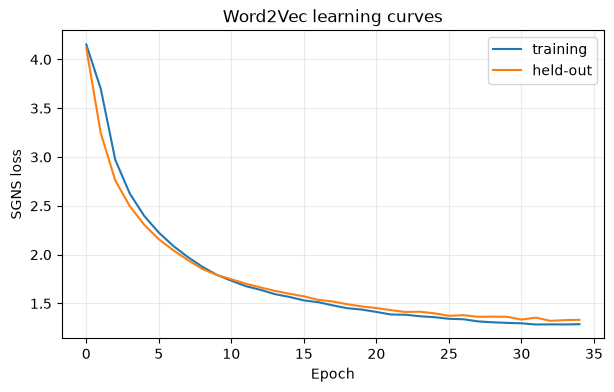

In [36]:
def train_word2vec(
    train_c, train_o, val_c, val_o, embedding_dim=30, num_negatives=5,
    epochs=35, batch_size=256, learning_rate=1.5, seed=42
):
    local_rng = np.random.default_rng(seed)
    model = SGNS(len(vocab), embedding_dim, local_rng)
    history = {'train': [], 'val': []}
    fixed_val_negatives = sample_negatives(len(val_c), num_negatives, val_o, local_rng)

    for epoch in range(epochs):
        permutation = local_rng.permutation(len(train_c))
        batch_losses = []
        for start in range(0, len(permutation), batch_size):
            idx = permutation[start:start + batch_size]
            c_batch, o_batch = train_c[idx], train_o[idx]
            negatives = sample_negatives(len(idx), num_negatives, o_batch, local_rng)
            batch_losses.append(model.step(c_batch, o_batch, negatives, learning_rate))

        train_loss = float(np.mean(batch_losses))
        val_loss = float(model.loss(val_c, val_o, fixed_val_negatives))
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch + 1:02d}: train={train_loss:.4f}, val={val_loss:.4f}')

    return model, history

model, history = train_word2vec(
    train_centers, train_contexts, val_centers, val_contexts
)

plt.figure(figsize=(7, 4))
plt.plot(history['train'], label='training')
plt.plot(history['val'], label='held-out')
plt.xlabel('Epoch')
plt.ylabel('SGNS loss')
plt.title('Word2Vec learning curves')
plt.legend()
plt.grid(alpha=0.25)
plt.show()




### Checkpoint 2

1. Did both curves decrease?
2. If training loss decreases while held-out loss rises, what is the likely interpretation?
3. Why does a low SGNS loss not prove that the embeddings encode factual knowledge?

**Your response:**  

1) Both curves decrease, showing the models improved at distinguishing context pairs.
2) If the training loss decreases while held-out loss rises, this would likely be due to overfitting.
3) Low SGNS loss only proves that there was a pattern of occurrences from the model. It does not mean that the embeddings encode factual knowledge, because co-occurrence can reflect limited, incomplete, or misleading patterns.


## 6. Evaluate nearest neighbors and analogies

In [37]:
def normalized_embeddings(model):
    # Combining input and output embeddings often gives a useful representation.
    E = model.W_in + model.W_out
    return E / np.maximum(np.linalg.norm(E, axis=1, keepdims=True), 1e-12)

E = normalized_embeddings(model)

def nearest_neighbors(word, top_k=6, embeddings=E):
    query_id = word_to_id[word]
    scores = embeddings @ embeddings[query_id]
    ranking = np.argsort(-scores)
    return [(id_to_word[i], float(scores[i])) for i in ranking if i != query_id][:top_k]

for word in ['king', 'queen', 'paris', 'dog', 'doctor', 'fruit']:
    print(f'\n{word}:', nearest_neighbors(word))

def analogy(a, b, c, top_k=5, embeddings=E):
    # b - a + c; for example, king - man + woman -> queen
    query = embeddings[word_to_id[b]] - embeddings[word_to_id[a]] + embeddings[word_to_id[c]]
    query = query / max(np.linalg.norm(query), 1e-12)
    scores = embeddings @ query
    excluded = {word_to_id[a], word_to_id[b], word_to_id[c]}
    ranking = [i for i in np.argsort(-scores) if i not in excluded]
    return [(id_to_word[i], float(scores[i])) for i in ranking[:top_k]]

print('king - man + woman:', analogy('man', 'king', 'woman'))
print('paris - france + germany:', analogy('france', 'paris', 'germany'))


king: [('queen', 0.9338466855664517), ('wears', 0.9272499610282587), ('crown', 0.6369850242327932), ('rule', 0.5186147005944853), ('a', 0.5075212547712894), ('prince', 0.4412086530781471)]

queen: [('king', 0.9338466855664517), ('rule', 0.7609964660043244), ('wears', 0.7522514991123781), ('kingdom', 0.5421912479704035), ('and', 0.43817774501925927), ('prince', 0.4327421560534238)]

paris: [('beijing', 0.9994844526872225), ('berlin', 0.9991188324537545), ('tokyo', 0.9987617888861795), ('rome', 0.9984656613633711), ('madrid', 0.9983139827583543), ('the', 0.9297076793110304)]

dog: [('cat', 0.9622522593971131), ('kitten', 0.8943610781723371), ('puppy', 0.8922492434868475), ('young', 0.8630564300895509), ('horse', 0.8194595078743117), ('is', 0.6864064814449319)]

doctor: [('teacher', 0.9751793976076633), ('teaches', 0.9576365428532911), ('treats', 0.9530217455540504), ('works', 0.945905649969933), ('student', 0.9420307384142805), ('learns', 0.9407386697805258)]

fruit: [('small', 0.934119

### Task 4 - Quantitative intrinsic evaluation

Measure whether a related target appears among the top five neighbors. This metric is deliberately small and interpretable; it is not a standardized benchmark.

In [38]:
RELATED_PAIRS = [
    ('king', 'queen'), ('prince', 'princess'), ('dog', 'cat'),
    ('puppy', 'kitten'), ('paris', 'berlin'), ('france', 'germany'),
    ('doctor', 'teacher'), ('hospital', 'school'), ('apple', 'banana')
]

def related_at_k(model, pairs, k=5):
    embeddings = normalized_embeddings(model)
    hits = []
    for query, target in pairs:
        neighbors = [w for w, _ in nearest_neighbors(query, k, embeddings)]
        hits.append(target in neighbors)
        print(f'{query:>8s} -> {target:<10s} | {neighbors} | hit={hits[-1]}')
    return float(np.mean(hits))

score = related_at_k(model, RELATED_PAIRS, k=5)
print(f'\nRelated@5 = {score:.3f}')

    king -> queen      | ['queen', 'wears', 'crown', 'rule', 'a'] | hit=True
  prince -> princess   | ['princess', 'and', 'grape', 'live', 'apple'] | hit=True
     dog -> cat        | ['cat', 'kitten', 'puppy', 'young', 'horse'] | hit=True
   puppy -> kitten     | ['kitten', 'dog', 'cat', 'young', 'is'] | hit=True
   paris -> berlin     | ['beijing', 'berlin', 'tokyo', 'rome', 'madrid'] | hit=True
  france -> germany    | ['japan', 'italy', 'china', 'germany', 'spain'] | hit=True
  doctor -> teacher    | ['teacher', 'teaches', 'treats', 'works', 'student'] | hit=True
hospital -> school     | ['school', 'learns', 'teacher', 'student', 'doctor'] | hit=True
   apple -> banana     | ['red', 'yellow', 'grape', 'orange', 'banana'] | hit=True

Related@5 = 1.000


## 7. Visualize selected embeddings

PCA is a projection: distances in two dimensions may distort relationships in the full embedding space.

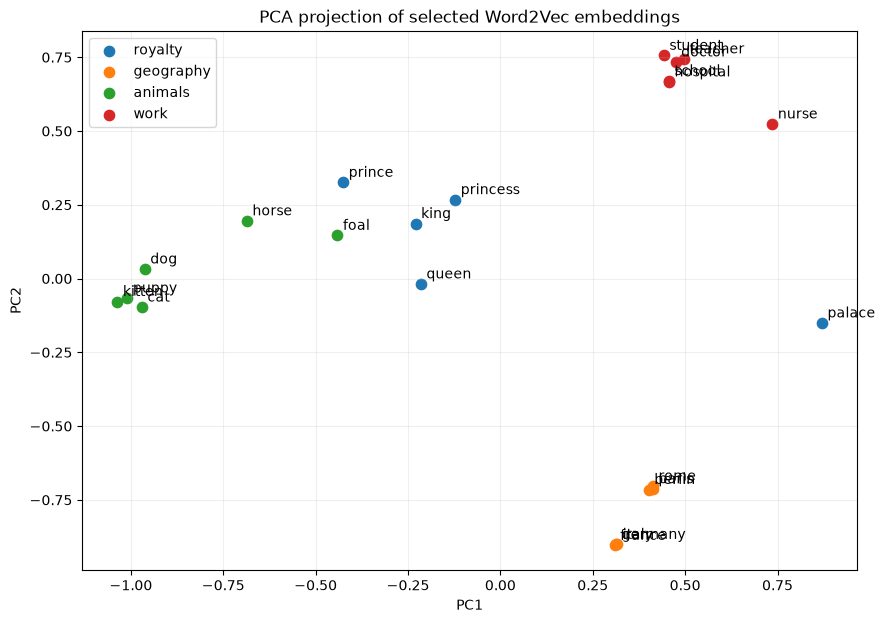

In [39]:
groups = {
    'royalty': ['king', 'queen', 'prince', 'princess', 'palace'],
    'geography': ['paris', 'france', 'berlin', 'germany', 'rome', 'italy'],
    'animals': ['dog', 'puppy', 'cat', 'kitten', 'horse', 'foal'],
    'work': ['doctor', 'nurse', 'hospital', 'teacher', 'student', 'school'],
}
selected = [word for words in groups.values() for word in words]
selected_ids = [word_to_id[w] for w in selected]
points = PCA(n_components=2).fit_transform(E[selected_ids])

plt.figure(figsize=(10, 7))
offset = 0
for label, words in groups.items():
    block = points[offset:offset + len(words)]
    plt.scatter(block[:, 0], block[:, 1], label=label, s=55)
    for word, (x, y) in zip(words, block):
        plt.annotate(word, (x, y), xytext=(4, 4), textcoords='offset points')
    offset += len(words)
plt.title('PCA projection of selected Word2Vec embeddings')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. Controlled experiment: context-window size

Train two otherwise identical models with window sizes 1 and 3. Record held-out loss, Related@5, qualitative neighbor differences, and runtime.

In [40]:
experiment_results = []
for window in [1, 3]:
    exp_c, exp_o = build_skipgram_pairs(encoded_sentences, window_size=window)
    exp_order = np.random.default_rng(RANDOM_STATE).permutation(len(exp_c))
    exp_split = int(0.90 * len(exp_order))
    tr, va = exp_order[:exp_split], exp_order[exp_split:]
    exp_model, exp_history = train_word2vec(
        exp_c[tr], exp_o[tr], exp_c[va], exp_o[va],
        epochs=25, seed=RANDOM_STATE
    )
    exp_score = related_at_k(exp_model, RELATED_PAIRS, k=5)
    experiment_results.append({
        'window': window,
        'pairs': len(exp_c),
        'final_val_loss': exp_history['val'][-1],
        'related_at_5': exp_score,
    })

experiment_results

Epoch 01: train=4.1584, val=4.1571
Epoch 05: train=2.6808, val=2.6021
Epoch 10: train=1.8378, val=1.8485
Epoch 15: train=1.4314, val=1.4532
Epoch 20: train=1.2239, val=1.2558
Epoch 25: train=1.1204, val=1.1322
    king -> queen      | ['and', 'prince', 'puppy', 'boy', 'wears'] | hit=False
  prince -> princess   | ['puppy', 'grape', 'apple', 'boy', 'purple'] | hit=False
     dog -> cat        | ['woman', 'cat', 'young', 'yellow', 'man'] | hit=True
   puppy -> kitten     | ['prince', 'grape', 'apple', 'and', 'purple'] | hit=False
   paris -> berlin     | ['berlin', 'rome', 'beijing', 'madrid', 'tokyo'] | hit=True
  france -> germany    | ['china', 'italy', 'germany', 'japan', 'spain'] | hit=True
  doctor -> teacher    | ['teacher', 'works', 'nurse', 'treats', 'teaches'] | hit=True
hospital -> school     | ['school', 'a', 'patient', 'loyal', 'student'] | hit=True
   apple -> banana     | ['grape', 'red', 'puppy', 'prince', 'purple'] | hit=False
Epoch 01: train=4.1427, val=4.0289
Epoch 05:

[{'window': 1,
  'pairs': 8160,
  'final_val_loss': 1.1321577576944568,
  'related_at_5': 0.5555555555555556},
 {'window': 3,
  'pairs': 18480,
  'final_val_loss': 1.4505709249681566,
  'related_at_5': 1.0}]

### Task 5 - Interpret the experiment

Report which window performed better under each metric. Explain why the result may differ between local syntactic relationships and broader semantic or topical relationships. Do not claim that one window is universally superior.

**Your response:**  

Window of 1 performed better on the held-out set, since the value was lower (~1.13), indicating that the model's predictions are closer to the actual target values than with window size 3 (~1.45). The window size 3 model performed better on the related@5 metric, as it consistently produced the expected related value for the top 5 associated words. A smaller window size emphasizes local syntactic relationships, whereas larger window sizes capture broader semantic or topical relationships by including words further from the center word.

## 9. Final analysis questions

Answer each in 3-5 sentences.

1. **Two embedding tables:** Why does SGNS learn both `W_in` and `W_out`? Why might we use `W_in`, `W_out`, or their sum at inference time?
2. **Polysemy:** This implementation assigns one vector to each word type. What happens to a word such as `bank` with multiple meanings?
3. **Bias:** How can social bias enter Word2Vec embeddings? Propose one diagnostic.
4. **Evaluation:** Why are nearest-neighbor examples and a two-dimensional PCA plot insufficient evidence of model quality?
5. **Extension:** Propose one experiment on a larger natural corpus, including a hypothesis, independent variable, dependent metric, and controlled variables.

**Your responses:**  

1) SGNS learns both `W_in` and `W_out` because each word serves the purpose of both being a center word and a context word. `W_in` represents a word when predicting nearby words, while `W_out` serves the purpose of representing the word as a context word. The sums of `W_in` and `W_out` could be used when combining information from both the role as a center and the context word. 
2) Words with multiple meanings would just get one vector. The vector for a word like 'bank' would be made up of both context and the more commonly used case, with the latter dominating the model. Since SGNS does not create a separate input and output for each meaning the results would end with blended definitions.
3) Social bias can enter Word2Vec because it relies on the context words surrounding the center word; if a word is repeatedly used with words that carry social bias, the model has no way to filter out that bias. There can also be social bias based on which materials the models are trained. One potential diagnostic is to compare similarities between related groups of words and then measure and report differences to see the association that arises due to some bias.
4) Nearest-neighbors can be insufficient evidence of model quality, since words can be selectively chosen while the embedding may not work well across the entire vocabulary. PCA plots are insufficient evidence of model quality because they flatten the dimensionality of the data, which can shrink or expand the apparent distances between words, leading to a poor understanding of model quality. This dimensionality shift preserves only part of the total information.
5) 
 - Larger corpus: A large collection of text based Quora posts.
 - Hypothesis: The larger context window(5, 10) would produce a stronger Related@5 score.
 - Independent variable: Context window size 2, 5, 10
 - Dependendent metric: Related@5 score on a held-out word-pair set
 - Controled variables: The corpus split, vocabulary, embedding dimension, negative-sample count, learning rate, training steps, random seed, and preprocessing.


## Submission checklist

- [X] All implementation cells run from top to bottom.
- [X] Gradient check passes.
- [X] Learning-curve plot is included.
- [X] Nearest-neighbor and analogy outputs are shown.
- [X] Window-size experiment is completed and interpreted.
- [X] Five final analysis questions are answered.
- [X] Meaningful AI assistance is disclosed.